### For each cell type, perform the comparison between our aging DEG list using pseudobulked analysis vs. NEBULA mixed-effect approach

- Specify a lower fold change threshold for the NEBULA approach, since the fold changes even for significant genes is quite small
- But use fold change for pseudobulked approach

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def extract_significant_NEBULA(df, direction, logFC_threshold = 0.1, p_val_threshold = 0.05):
    '''Get either the significant up or down DEGs from a pydeseq2 directory''' 
    if direction == "up":
        sig_df = df[(df['p_adj_age_groupold'] < p_val_threshold) & (df['logFC_age_groupold'] > logFC_threshold)].copy()
        sig_df['direction']  = direction
    elif direction == "down":
        sig_df = df[(df['p_adj_age_groupold'] < p_val_threshold) & (df['logFC_age_groupold'] < -1 * logFC_threshold)].copy()
        sig_df['direction'] = direction
    else: 
        raise ValueError("direction must be 'up' or 'down'!")
    return sig_df

In [3]:
def extract_significant_pydeseq2(df, direction, logFC_threshold = 0.5, p_val_threshold = 0.05):
    '''Get either the significant up or down DEGs from a pydeseq2 directory''' 
    if direction == "up":
        sig_df = df[(df['log2FoldChange'] > logFC_threshold) & (df['padj'] < p_val_threshold)].copy()
        sig_df['direction']  = direction
    elif direction == "down":
        sig_df = df[(df['log2FoldChange'] < -logFC_threshold) & (df['padj'] < p_val_threshold)].copy()
        sig_df['direction']  = direction
    else: 
        raise ValueError("direction must be 'up' or 'down'!")
    return sig_df

In [4]:
def compare_DEGs(our_df, NEB_df, our_gene_col="gene_id", NEB_gene_col="gene", 
                direction_col="direction"):
    '''Compare DEGs between the two approaches'''
    
    # generate sets
    our_up   = set(our_df.loc[our_df[direction_col]=="up",   our_gene_col])
    our_down = set(our_df.loc[our_df[direction_col]=="down", our_gene_col])
    
    NEB_up   = set(NEB_df.loc[NEB_df[direction_col]=="up",   NEB_gene_col])
    NEB_down = set(NEB_df.loc[NEB_df[direction_col]=="down", NEB_gene_col])
    
    results = {
        "shared_up":   len(our_up & NEB_up),
        "shared_down": len(our_down & NEB_down),
        "up_pseudo": len(our_up - NEB_up),
        "down_pseudo": len(our_down - NEB_down),
        "up_NEBULA": len(NEB_up - our_up),
        "down_NEBULA": len(NEB_down - our_down),
    }
    
    return results

### Test for one cell type

In [5]:
NEBULA_dir = "../../../NEBULA_analysis/NEBULA_results/"

In [6]:
NEBULA_DEG_df = pd.read_csv(NEBULA_dir + "Cardiomyocyte.csv", index_col = 0)
NEBULA_DEG_df

,logFC_(Intercept),logFC_sexmale,logFC_age_groupmiddle,logFC_age_groupold,logFC_tech_plus_study3prime-v2_Litvinukova 2020,logFC_tech_plus_study3prime-v3_Chaffin 2022,logFC_tech_plus_study3prime-v3_Hill 2022,logFC_tech_plus_study3prime-v3_Kuppe 2022,logFC_tech_plus_study3prime-v3_Litvinukova 2020,logFC_tech_plus_study3prime-v3_Reichart 2022,...,p_tech_plus_study3prime-v3_Reichart 2022,p_tech_plus_study3prime-v3_Simonson 2023,p_tech_plus_study5prime-v1_Koenig 2022,p_tech_plus_studyDropseq_Penn,p_tech_plus_studyMultiome-v1_ENCODE v4 (Snyder),p_tech_plus_studyMultiome-v1_Kanemaru 2023,gene_id,gene,p_adj_age_groupold,p_adj_sexmale
1,-14.530061,0.066682,-0.138607,-0.071521,1.486452,0.105827,1.056344,0.559947,0.992394,1.086054,...,8.521787e-06,1.122742e-01,9.838294e-01,2.107457e-01,0.334294,0.000656,2,LINC00115,1.000000e+00,1.000000
2,-11.081048,0.083093,0.050325,-0.001758,0.439968,0.089570,0.697795,0.254756,0.511966,0.633480,...,4.122747e-06,1.240812e-01,6.312957e-06,1.623901e-01,0.097876,0.131659,5,NOC2L,1.000000e+00,1.000000
3,-13.677883,0.043347,-0.021841,-0.205939,-0.562196,-0.893861,0.317171,0.297000,0.400572,0.341208,...,2.034950e-01,4.794541e-01,2.407663e-03,9.745629e-02,0.581961,0.150946,6,KLHL17,1.000000e+00,1.000000
4,-12.943395,0.010228,0.229187,0.177214,-1.881569,1.805808,0.351666,1.037167,0.643931,0.354084,...,2.604066e-01,3.247776e-12,4.975493e-10,9.892140e-01,0.000082,0.001995,7,PLEKHN1,1.000000e+00,1.000000
5,-10.890034,0.170627,-0.097929,-0.087122,0.444883,0.662959,2.138900,0.600201,2.170139,1.607047,...,5.579816e-04,5.941070e-01,5.734329e-01,1.485101e-01,0.000024,0.211056,8,HES4,1.000000e+00,0.000001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12923,-12.301294,-0.191875,0.230267,0.281504,-3.039029,-4.205071,-0.253364,-1.884008,-4.321682,-2.223346,...,1.120421e-09,6.174872e-26,8.472806e-07,4.054360e-03,0.018940,0.011987,16111,MT-ND4L,1.000000e+00,1.000000
12924,-10.411454,-0.029678,0.461119,0.483199,-2.346658,-4.321616,-0.598295,-1.906866,-4.363663,-2.144141,...,3.052251e-08,1.245670e-37,9.432368e-03,1.054056e-08,0.252041,0.111572,16112,MT-ND4,3.517971e-14,1.000000
12925,-11.591058,-0.112275,0.017398,0.208266,-2.768985,-4.163103,-0.766296,-1.536789,-4.865461,-2.067358,...,6.102584e-11,1.549620e-35,9.442326e-02,2.094579e-04,0.413316,0.203486,16113,MT-ND5,1.000000e+00,1.000000
12926,-12.625606,-0.133176,0.172359,0.125626,-2.043817,-2.215978,-1.239546,-0.377680,-4.320384,-0.531247,...,1.560458e-01,7.521143e-12,2.059594e-02,9.837265e-01,0.595807,0.020599,16114,MT-ND6,1.000000e+00,1.000000


In [7]:
sig_NEBULA_DEG_df = extract_significant_NEBULA(NEBULA_DEG_df, direction = "down")
sig_NEBULA_DEG_df

,logFC_(Intercept),logFC_sexmale,logFC_age_groupmiddle,logFC_age_groupold,logFC_tech_plus_study3prime-v2_Litvinukova 2020,logFC_tech_plus_study3prime-v3_Chaffin 2022,logFC_tech_plus_study3prime-v3_Hill 2022,logFC_tech_plus_study3prime-v3_Kuppe 2022,logFC_tech_plus_study3prime-v3_Litvinukova 2020,logFC_tech_plus_study3prime-v3_Reichart 2022,...,p_tech_plus_study3prime-v3_Simonson 2023,p_tech_plus_study5prime-v1_Koenig 2022,p_tech_plus_studyDropseq_Penn,p_tech_plus_studyMultiome-v1_ENCODE v4 (Snyder),p_tech_plus_studyMultiome-v1_Kanemaru 2023,gene_id,gene,p_adj_age_groupold,p_adj_sexmale,direction
26,-10.777161,0.020920,-0.189414,-0.186961,-0.270877,0.175647,0.655000,-0.206122,1.838564,0.772557,...,5.941481e-03,3.439390e-01,0.004738,0.000807,0.005049,36,MMP23B,1.039830e-02,1.000000e+00,down
109,-10.962066,-0.389108,-0.489690,-0.638705,-0.443757,-1.678907,-1.783107,-1.569497,-1.701650,-1.927986,...,6.269417e-03,7.715975e-01,0.160407,0.000387,0.585924,138,NPPA,1.816082e-04,1.038044e-05,down
110,-10.056751,0.056816,-0.496121,-0.462633,1.459762,-0.833859,0.821882,-2.337200,0.132725,1.276212,...,5.374202e-01,7.937210e-01,0.202343,0.032442,0.022871,139,NPPB,2.819142e-10,1.000000e+00,down
201,-8.954387,0.049564,-0.146512,-0.132878,0.311233,-0.045304,-1.557956,0.150954,0.632116,0.568915,...,2.016916e-01,3.105311e-08,0.001080,0.140650,0.966540,257,SRSF10,9.418963e-08,1.679101e-01,down
280,-10.220247,0.020914,-0.184190,-0.178776,0.566025,-0.028662,0.452741,-0.442441,0.800948,0.669976,...,5.925686e-01,2.338633e-07,0.782885,0.171176,0.018196,353,TINAGL1,1.980273e-03,1.000000e+00,down
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12579,-10.733109,0.060247,-0.140154,-0.256839,0.372532,-0.565044,0.223478,-0.156325,0.374850,0.316669,...,3.802426e-01,9.055247e-05,0.060362,0.242475,0.013662,15673,RBM3,9.235715e-04,1.000000e+00,down
12668,-8.938781,-0.033684,-0.130276,-0.107654,-0.596708,0.188813,-0.106182,-0.038306,-0.089231,-0.095498,...,6.872726e-01,8.757230e-03,0.750423,0.029556,0.231387,15785,OGT,1.093716e-03,1.000000e+00,down
12831,-7.980333,0.068500,-0.142087,-0.125711,0.388566,0.313834,0.020023,0.178680,0.248627,0.711371,...,7.794743e-01,1.866825e-02,0.000572,0.004667,0.050115,15999,FHL1,5.787782e-07,7.709420e-09,down
12852,-10.220882,-0.057666,-0.249122,-0.252659,-0.552193,0.227757,-0.974307,0.405225,0.310781,0.243761,...,9.444177e-01,4.525058e-09,0.840104,0.000799,0.324690,16027,GABRE,3.812277e-03,1.000000e+00,down


In [8]:
our_DEG_df = pd.read_csv("../pydeseq2_results/Cardiomyocyte_age_group_old_vs_young_results.csv", index_col = 0)
our_DEG_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_id,-log10(padj),significant
STEAP4,41.776701,-2.130411,0.335202,-6.355604,2.076086e-10,0.000003,STEAP4,5.501569,True
COL3A1,125.740776,-2.321635,0.377090,-6.156713,7.427021e-10,0.000006,COL3A1,5.249029,True
RTKN,113.292610,-0.473577,0.086763,-5.458303,4.807066e-08,0.000243,RTKN,3.614055,False
LDLR,78.469255,-2.151205,0.400395,-5.372702,7.756527e-08,0.000294,LDLR,3.531207,True
CILP,17.337422,-1.882908,0.368501,-5.109649,3.227575e-07,0.000980,CILP,3.008908,True
...,...,...,...,...,...,...,...,...,...
LINC00536,28.484082,-0.000166,0.198339,-0.000838,9.993317e-01,0.999616,LINC00536,0.000167,False
HLTF-AS1,5.033411,0.000142,0.236865,0.000601,9.995201e-01,0.999718,HLTF-AS1,0.000123,False
MBD1,215.246439,0.000029,0.056705,0.000514,9.995898e-01,0.999722,MBD1,0.000121,False
NUDC,282.273486,0.000026,0.061331,0.000429,9.996575e-01,0.999723,NUDC,0.000120,False


In [9]:
sig_df = extract_significant_pydeseq2(our_DEG_df, direction="down")
sig_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_id,-log10(padj),significant,direction
STEAP4,41.776701,-2.130411,0.335202,-6.355604,2.076086e-10,0.000003,STEAP4,5.501569,True,down
COL3A1,125.740776,-2.321635,0.377090,-6.156713,7.427021e-10,0.000006,COL3A1,5.249029,True,down
LDLR,78.469255,-2.151205,0.400395,-5.372702,7.756527e-08,0.000294,LDLR,3.531207,True,down
CILP,17.337422,-1.882908,0.368501,-5.109649,3.227575e-07,0.000980,CILP,3.008908,True,down
COL1A2,115.205329,-1.730437,0.342534,-5.051865,4.375176e-07,0.000985,COL1A2,3.006603,True,down
...,...,...,...,...,...,...,...,...,...,...
CCDC80,108.143191,-1.080229,0.319100,-3.385237,7.111684e-04,0.048400,CCDC80,1.315156,True,down
MFAP2,7.439333,-0.967098,0.288496,-3.352202,8.017150e-04,0.049476,MFAP2,1.305606,True,down
STEAP3,53.091886,-0.650879,0.194288,-3.350075,8.078976e-04,0.049476,STEAP3,1.305606,True,down
NLGN2,19.864127,-0.677128,0.202099,-3.350478,8.067212e-04,0.049476,NLGN2,1.305606,True,down


### Iterate through all cell types

In [10]:
shared_cell_types = ['Adipocyte', 'Cardiomyocyte', 'Endocardial', 'Endothelial', 'Epicardial', 'Fibroblast',
                     'LEC', 'Lymphoid', 'Mast', 'Myeloid', 'Neuronal', 'Pericyte', 'vSMC']

In [11]:
results_list = list()

for cell_type in shared_cell_types:

    # extract significant DEGs in NEBULA approach
    NEBULA_DEG_df = pd.read_csv(NEBULA_dir + cell_type + ".csv", index_col = 0)
    NEB_sig_up_df = extract_significant_NEBULA(NEBULA_DEG_df, direction="up")
    NEB_sig_down_df = extract_significant_NEBULA(NEBULA_DEG_df, direction="down")
    NEB_concat_sig_df = pd.concat([NEB_sig_up_df, NEB_sig_down_df])

    # extract significant DEGs in pseudobulked approach
    our_DEG_df = pd.read_csv("../pydeseq2_results/" + cell_type + "_age_group_old_vs_young_results.csv", index_col = 0)
    sig_up_df = extract_significant_pydeseq2(our_DEG_df, direction="up")
    sig_down_df = extract_significant_pydeseq2(our_DEG_df, direction="down")
    concat_sig_df = pd.concat([sig_up_df, sig_down_df])
    
    # compare up DEGs
    results = compare_DEGs(our_df=concat_sig_df, NEB_df=NEB_concat_sig_df)
    results['cell_type'] = cell_type

    # append both
    results_list.append(results)

results_df = pd.DataFrame(results_list)

In [12]:
results_df

,shared_up,shared_down,up_pseudo,down_pseudo,up_NEBULA,down_NEBULA,cell_type
0,0,0,10,95,9,2,Adipocyte
1,4,3,46,90,110,171,Cardiomyocyte
2,0,1,1,2,0,0,Endocardial
3,0,0,0,1,2,17,Endothelial
4,1,0,0,0,0,10,Epicardial
5,1,1,46,39,81,17,Fibroblast
6,0,0,0,21,1,1,LEC
7,0,1,0,0,6,2,Lymphoid
8,0,0,0,0,0,0,Mast
9,0,2,26,50,6,2,Myeloid


/mnt/data1/william/tmp/ipykernel_1131400/1388142729.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  heatmap_colors = heatmap_df.applymap(lambda x: np.log1p(x))


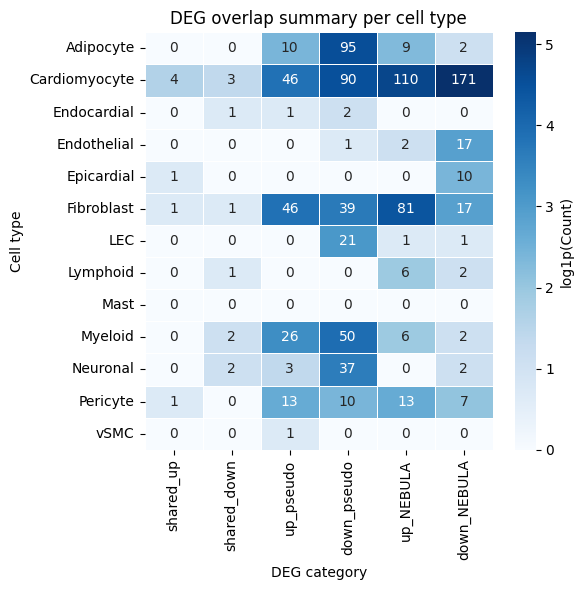

In [13]:
# select metrics
heatmap_df = results_df.set_index("cell_type")[
    ["shared_up", "shared_down", "up_pseudo", "down_pseudo", "up_NEBULA", "down_NEBULA"]
]

custom_order = shared_cell_types

heatmap_df = heatmap_df.reindex(custom_order)

# Color values on log scale
heatmap_colors = heatmap_df.applymap(lambda x: np.log1p(x))

plt.figure(figsize=(6,6))
sns.heatmap(
    heatmap_colors,
    cmap="Blues",           
    annot=heatmap_df,      
    fmt=".0f",
    linewidths=0.5,
    cbar_kws={"label": "log1p(Count)"}
)
plt.title("DEG overlap summary per cell type")
plt.ylabel("Cell type")
plt.xlabel("DEG category")
plt.tight_layout()

plt.savefig("Pseudobulk_vs_NEBULA_aging_DEGs.pdf")
plt.show()